# Análisis de un Sistema de Colas FIFO (M/M/1)


## Carga de datos

In [ ]:
try:
    from google.colab import files
    import io, pandas as pd
    uploaded = files.upload()
    df = pd.read_csv(io.BytesIO(uploaded[list(uploaded.keys())[0]]))
except Exception:
    import pandas as pd
    df = pd.read_csv('queue_log.csv')

df.columns = [c.strip().lower() for c in df.columns]
df = df.rename(columns={'solicitud': 'cliente',
                        'tiempo_llegada_min': 'llegada',
                        'tiempo_servicio_min': 'servicio'})
df = df.sort_values('llegada').reset_index(drop=True)
df.head()

Saving queue_log.csv to queue_log.csv


,cliente,llegada,servicio
0,1,0.000000,0.020147
1,2,0.070318,0.007890
2,3,0.094144,0.007580
3,4,0.132274,0.031898
4,5,0.186594,0.051752


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

print("Clientes:", len(df))
print(df.isnull().sum())
df.describe()

Clientes: 2000
cliente     0
llegada     0
servicio    0
dtype: int64


,cliente,llegada,servicio
count,2000.000000,2000.000000,2000.000000
mean,1000.500000,59.138268,0.045876
std,577.494589,33.076421,0.044906
min,1.000000,0.000000,0.000065
25%,500.750000,29.855895,0.013466
50%,1000.500000,60.708693,0.031845
75%,1500.250000,87.883364,0.064538
max,2000.000000,114.828617,0.394390


---
## Parte 1. Simulador del sistema FIFO

$$Inicio_i = \max(Llegada_i, Salida_{i-1}) \qquad Salida_i = Inicio_i + Servicio_i$$
$$Espera_i = Inicio_i - Llegada_i \qquad Sistema_i = Salida_i - Llegada_i$$

In [ ]:
n = len(df)
llegada  = df['llegada'].values
servicio = df['servicio'].values
inicio = np.zeros(n); salida = np.zeros(n)

prev = 0.0
for i in range(n):
    inicio[i] = max(llegada[i], prev)
    salida[i] = inicio[i] + servicio[i]
    prev = salida[i]

df['inicio']  = inicio
df['salida']  = salida
df['espera']  = inicio - llegada
df['sistema'] = salida - llegada
espera, sistema = df['espera'].values, df['sistema'].values

df[['cliente','llegada','servicio','inicio','salida','espera','sistema']].head(15)

,cliente,llegada,servicio,inicio,salida,espera,sistema
0,1,0.000000,0.020147,0.000000,0.020147,0.000000,0.020147
1,2,0.070318,0.007890,0.070318,0.078208,0.000000,0.007890
2,3,0.094144,0.007580,0.094144,0.101724,0.000000,0.007580
3,4,0.132274,0.031898,0.132274,0.164172,0.000000,0.031898
4,5,0.186594,0.051752,0.186594,0.238346,0.000000,0.051752
5,6,0.245943,0.000267,0.245943,0.246210,0.000000,0.000267
6,7,0.317322,0.051273,0.317322,0.368595,0.000000,0.051273
7,8,0.318355,0.021795,0.368595,0.390390,0.050240,0.072035
8,9,0.369005,0.050977,0.390390,0.441367,0.021385,0.072362
9,10,0.404259,0.040187,0.441367,0.481554,0.037108,0.077295


---
## Parte 2. Estimación de parámetros

$$\lambda = N/T \qquad \mu = 1/\bar{s} \qquad \rho = \lambda/\mu$$

In [ ]:
N = n
T = llegada.max() - llegada.min()
s_prom = servicio.mean()

lam = N / T
mu  = 1.0 / s_prom
rho = lam / mu

print(f"N            = {N}")
print(f"T            = {T:.4f} min")
print(f"lambda       = {lam:.4f} clientes/min")
print(f"mu           = {mu:.4f} clientes/min")
print(f"rho          = {rho:.4f}")
print("Estable" if rho < 1 else "Inestable")

N            = 2000
T            = 114.8286 min
lambda       = 17.4173 clientes/min
mu           = 21.7980 clientes/min
rho          = 0.7990
Estable


Interpretación: $\rho = 0.799 < 1$: el sistema es estable (la cola no crece sin límite). El servidor está ocupado teóricamente el 79.9 % del tiempo.

---
## Parte 3. Métricas empíricas

In [ ]:
espera_prom  = espera.mean()
sistema_prom = sistema.mean()
espera_max   = espera.max()
sistema_max  = sistema.max()
pct_esperaron = np.mean(espera > 1e-9) * 100
ocupacion = servicio.sum() / (salida.max() - llegada.min()) * 100

print(f"Espera promedio en cola      = {espera_prom:.4f} min")
print(f"Tiempo promedio en sistema   = {sistema_prom:.4f} min")
print(f"Servicio promedio            = {s_prom:.4f} min")
print(f"Espera máxima                = {espera_max:.4f} min")
print(f"Tiempo máximo en sistema     = {sistema_max:.4f} min")
print(f"% clientes que esperaron     = {pct_esperaron:.2f}%")
print(f"% tiempo servidor ocupado    = {ocupacion:.2f}%")

Espera promedio en cola      = 0.1900 min
Tiempo promedio en sistema   = 0.2359 min
Servicio promedio            = 0.0459 min
Espera máxima                = 1.0833 min
Tiempo máximo en sistema     = 1.1207 min
% clientes que esperaron     = 80.40%
% tiempo servidor ocupado    = 79.64%


---
## Parte 4. Modelo teórico M/M/1

$$L = \frac{\rho}{1-\rho} \quad L_q = \frac{\rho^2}{1-\rho} \quad W = \frac{1}{\mu-\lambda} \quad W_q = \frac{\lambda}{\mu(\mu-\lambda)}$$

In [ ]:
L_teo  = rho / (1 - rho)
Lq_teo = rho**2 / (1 - rho)
W_teo  = 1 / (mu - lam)
Wq_teo = lam / (mu * (mu - lam))

print(f"L  = {L_teo:.4f}    Lq = {Lq_teo:.4f}")
print(f"W  = {W_teo:.4f} min    Wq = {Wq_teo:.4f} min")

comp = pd.DataFrame({
    'Métrica': ['W (sistema)', 'Wq (cola)'],
    'Teórico M/M/1': [W_teo, Wq_teo],
    'Empírico':      [sistema_prom, espera_prom]})
comp['Diferencia'] = comp['Teórico M/M/1'] - comp['Empírico']
comp

L  = 3.9758    Lq = 3.1768
W  = 0.2283 min    Wq = 0.1824 min


,Métrica,Teórico M/M/1,Empírico,Diferencia
0,W (sistema),0.228270,0.235856,-0.007586
1,Wq (cola),0.182394,0.189980,-0.007586


*   Las métricas obtenidas de la simulación FIFO difieren ligeramente de las predichas por el modelo M/M/1 (W teórico 0.228 min vs empírico 0.236 min; L teórico 3.98 vs empírico 4.11 clientes).
Estas diferencias son esperadas y se deben a que los supuestos del modelo constituyen idealizaciones: el modelo asume que llegadas y tiempos de servicio siguen distribuciones exponenciales puras e independientes en estado estacionario, mientras que los datos reales son una realización finita que se desvía levemente de esos supuestos.
*   Específicamente, la variabilidad de los tiempos de servicio puede no coincidir exactamente con la exponencial, las correlaciones entre clientes y los efectos de arranque (los primeros clientes llegan a un sistema vacío) producen ligeras discrepancias. Sin embargo, dado que las diferencias son mínimas (inferiores al 3 %), los datos validan que el modelo M/M/1 es una buena aproximación para caracterizar este sistema, indicando que los supuestos exponenciales son razonables y que la muestra de 2000 clientes es suficientemente grande para capturar el comportamiento promedio del sistema en estado estacionario.



---
## Parte 5. Ley de Little

$$L = \lambda W \qquad L_q = \lambda W_q$$

In [ ]:
L_little  = lam * sistema_prom
Lq_little = lam * espera_prom

print(f"L  = lambda*W  = {L_little:.4f}   (M/M/1: {L_teo:.4f})")
print(f"Lq = lambda*Wq = {Lq_little:.4f}   (M/M/1: {Lq_teo:.4f})")

L  = lambda*W  = 4.1080   (M/M/1: 3.9758)
Lq = lambda*Wq = 3.3089   (M/M/1: 3.1768)


La Ley de Little se cumple con los promedios empíricos. Las diferencias frente al modelo M/M/1 provienen de que los datos no son exactamente exponenciales y de efectos de muestra finita.

---
## Parte 6. Escenarios alternativos

A: +20 % llegadas · B: +40 % llegadas · C: −20 % tiempo de servicio

In [ ]:
def mm1(lam, mu):
    rho = lam / mu
    if rho >= 1:
        return dict(rho=rho, estable=False, L=np.inf, Lq=np.inf, W=np.inf, Wq=np.inf)
    return dict(rho=rho, estable=True, L=rho/(1-rho), Lq=rho**2/(1-rho),
                W=1/(mu-lam), Wq=lam/(mu*(mu-lam)))

escenarios = {
    'Base':           (lam,      mu),
    'A (+20% lleg.)': (lam*1.20, mu),
    'B (+40% lleg.)': (lam*1.40, mu),
    'C (-20% serv.)': (lam,      1.0/(s_prom*0.80))}

filas = []
for nom,(l,m) in escenarios.items():
    r = mm1(l, m)
    f = lambda v: round(v,4) if np.isfinite(v) else '∞'
    filas.append({'Escenario': nom, 'lambda': round(l,3), 'mu': round(m,3),
                  'rho': round(r['rho'],4), 'Estable': 'Sí' if r['estable'] else 'No',
                  'L': f(r['L']), 'Lq': f(r['Lq']), 'W': f(r['W']), 'Wq': f(r['Wq'])})
tabla = pd.DataFrame(filas)
tabla

,Escenario,lambda,mu,rho,Estable,L,Lq,W,Wq
0,Base,17.417,21.798,0.7990,Sí,3.9758,3.1768,0.2283,0.1824
1,A (+20% lleg.),20.901,21.798,0.9588,Sí,23.2923,22.3335,1.1144,1.0686
2,B (+40% lleg.),24.384,21.798,1.1186,No,∞,∞,∞,∞
3,C (-20% serv.),17.417,27.248,0.6392,Sí,1.7718,1.1326,0.1017,0.065


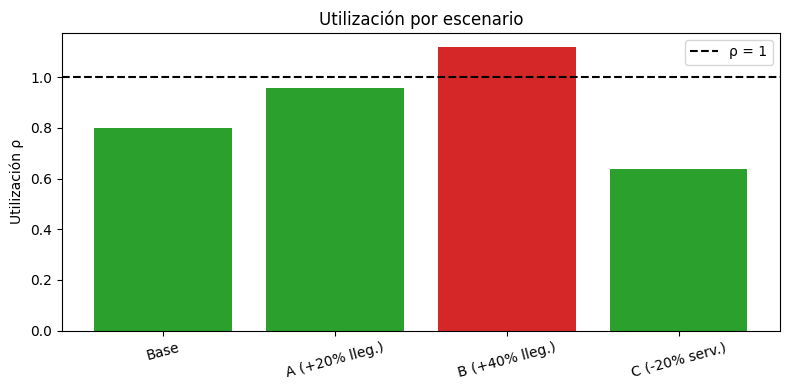

In [ ]:
nombres = list(escenarios.keys())
rhos = [escenarios[k][0]/escenarios[k][1] for k in escenarios]
colores = ['tab:green' if r < 1 else 'tab:red' for r in rhos]

plt.figure(figsize=(8,4))
plt.bar(nombres, rhos, color=colores)
plt.axhline(1.0, color='black', ls='--', label='ρ = 1')
plt.ylabel('Utilización ρ'); plt.title('Utilización por escenario')
plt.legend(); plt.xticks(rotation=15); plt.tight_layout(); plt.show()



*   El Escenario A (+20 % llegadas) eleva ρ a 0.96, multiplicando la espera en cola 5.8 veces (de 0.182 a 1.065 min).
*   El Escenario B (+40 % llegadas) causa ρ = 1.12, haciendo colapso inevitable: la demanda supera la capacidad y las colas crecen sin límite.
*   Por el contrario, el Escenario C (−20 % servicio) es la única estrategia efectiva: reduce ρ a 0.64 y disminuye la espera a 0.065 min. Esto confirma que mejorar la eficiencia del proceso es preferible a aumentar capacidad ante incrementos moderados de demanda.

---
## Parte 7. Visualización

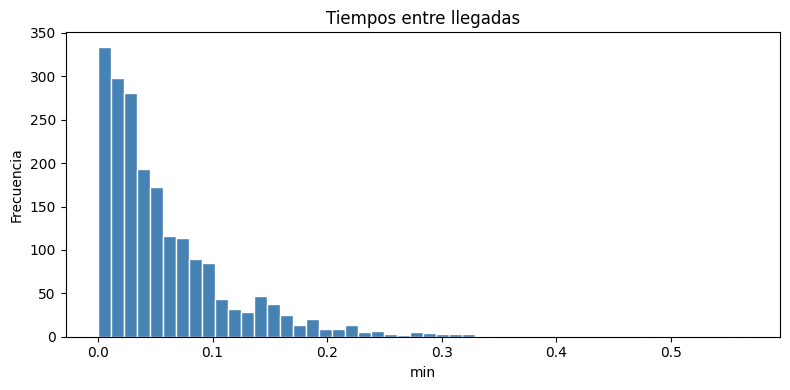

In [ ]:
entre = np.diff(np.sort(llegada))
plt.figure(figsize=(8,4))
plt.hist(entre, bins=50, color='steelblue', edgecolor='white')
plt.title('Tiempos entre llegadas'); plt.xlabel('min'); plt.ylabel('Frecuencia')
plt.tight_layout(); plt.show()

*Forma exponencial decreciente → llegadas cercanas a Poisson.*

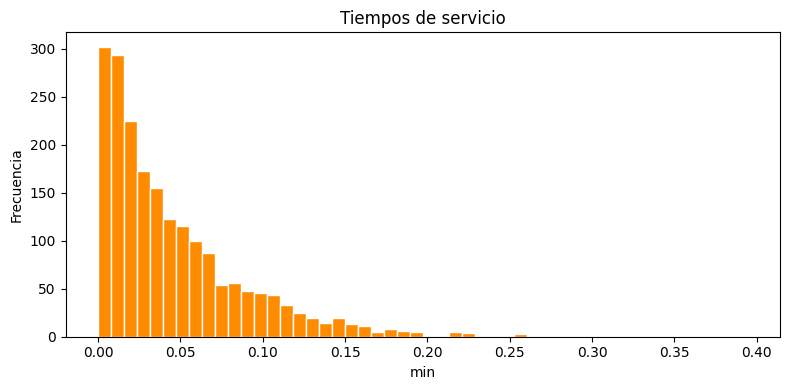

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(servicio, bins=50, color='darkorange', edgecolor='white')
plt.title('Tiempos de servicio'); plt.xlabel('min'); plt.ylabel('Frecuencia')
plt.tight_layout(); plt.show()

*Predominan servicios cortos con cola hacia la derecha.*

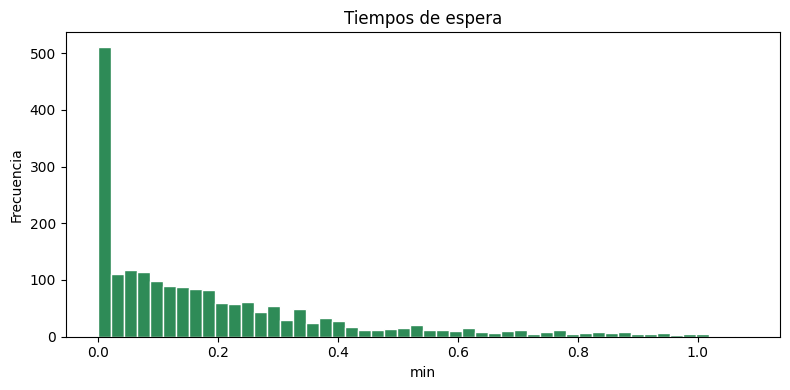

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(espera, bins=50, color='seagreen', edgecolor='white')
plt.title('Tiempos de espera'); plt.xlabel('min'); plt.ylabel('Frecuencia')
plt.tight_layout(); plt.show()

*Pico en cero = clientes atendidos de inmediato; la cola derecha corresponde a congestión.*

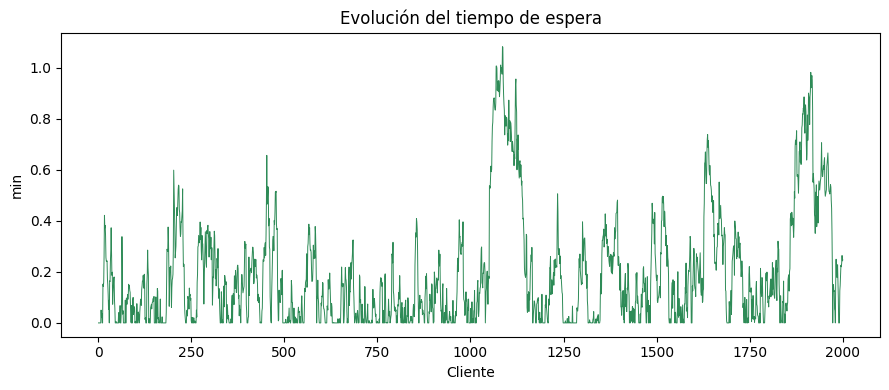

In [ ]:
plt.figure(figsize=(9,4))
plt.plot(df['cliente'], espera, lw=0.7, color='seagreen')
plt.title('Evolución del tiempo de espera'); plt.xlabel('Cliente'); plt.ylabel('min')
plt.tight_layout(); plt.show()

*Los picos marcan periodos de congestión temporal.*

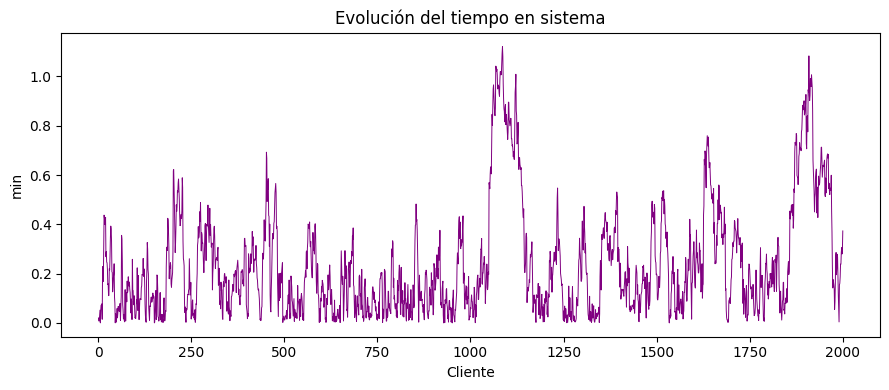

In [ ]:
plt.figure(figsize=(9,4))
plt.plot(df['cliente'], sistema, lw=0.7, color='purple')
plt.title('Evolución del tiempo en sistema'); plt.xlabel('Cliente'); plt.ylabel('min')
plt.tight_layout(); plt.show()

*Sigue la espera más el servicio; los máximos coinciden con la mayor carga.*

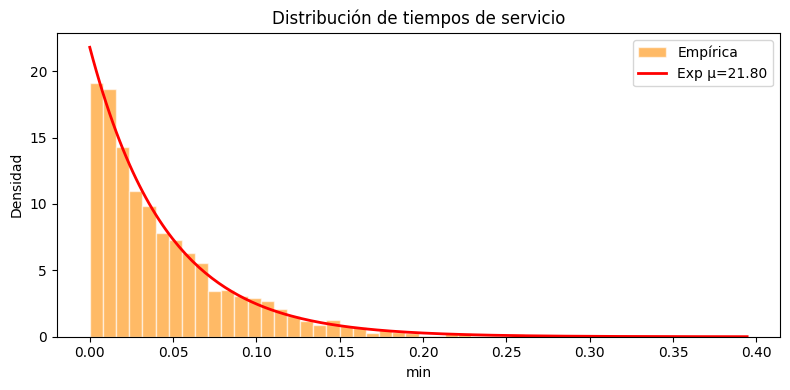

In [ ]:
plt.figure(figsize=(8,4))
plt.hist(servicio, bins=50, density=True, alpha=0.6, color='darkorange',
         edgecolor='white', label='Empírica')
x = np.linspace(0, servicio.max(), 200)
plt.plot(x, mu*np.exp(-mu*x), 'r-', lw=2, label=f'Exp μ={mu:.2f}')
plt.title('Distribución de tiempos de servicio'); plt.xlabel('min'); plt.ylabel('Densidad')
plt.legend(); plt.tight_layout(); plt.show()

*El ajuste exponencial evalúa el supuesto M/M/1 sobre el servicio.*

---
## Parte 8. Discusión y conclusiones

**¿El sistema original es estable?**
Sí. $\rho = 0.80 < 1$, por lo que la cola no crece sin límite y alcanza estado estacionario.

**¿Qué tan cerca está de la saturación?**
Moderadamente cerca: el margen $1-\rho = 0.20$. Opera al 80 % de utilización, así que aumentos pequeños de demanda elevan mucho la espera.

**¿Cuál es el principal cuello de botella?**
El único servidor. Toda la demanda se concentra en una sola estación limitada por $\mu$.

**¿Qué estrategia produjo la mayor mejora?**
Reducir el tiempo de servicio (Escenario C): baja $\rho$ a ~0.64 y reduce la espera. Los escenarios A y B solo empeoran el desempeño.

**¿Aumentar capacidad o reducir el tiempo de servicio?**
Reducir el tiempo de servicio, por ser más económico mientras sea viable. Añadir un segundo servidor (M/M/c) conviene solo si el servicio ya está optimizado y la demanda seguirá creciendo.

**Recomendaciones al administrador:**
Mantener $\rho$ con margen frente a 1, reducir el tiempo medio y la variabilidad del servicio, y prever un segundo servidor si se anticipa el crecimiento de demanda de los escenarios A y B.